# Visualize Shapes Across All CadBench Groups

This notebook samples and renders a few STL shapes from **every group** in `cadbench_stls/cadbench_stl_normalized`:
- `bench0`, `bench1A`, `bench1B` (each with `easy`, `medium`, `hard`)
- `bench2`, `bench3`

In [5]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
import trimesh

In [17]:
ROOT = Path('/home/nicksung/Desktop/nicksung/multimodel_class')
CADBENCH_ROOT = ROOT / 'cadbench_stls' / 'cadbench_stl_normalized'

RANDOM_SEED = 42
PICK_MODE = 'random'  # 'random' or 'first'
SAMPLES_PER_GROUP = 3
BENCH_ORDER = ['bench0', 'bench1A', 'bench1B', 'bench2', 'bench3']

assert CADBENCH_ROOT.exists(), f'Missing dataset root: {CADBENCH_ROOT}'
print('Using CadBench root:', CADBENCH_ROOT)
print('SAMPLES_PER_GROUP:', SAMPLES_PER_GROUP)
print('PICK_MODE:', PICK_MODE)

Using CadBench root: /home/nicksung/Desktop/nicksung/multimodel_class/cadbench_stls/cadbench_stl_normalized
SAMPLES_PER_GROUP: 3
PICK_MODE: random


In [15]:
def load_mesh(stl_path: Path) -> trimesh.Trimesh:
    mesh = trimesh.load(stl_path, force='mesh')
    if isinstance(mesh, trimesh.Scene):
        mesh = trimesh.util.concatenate(tuple(mesh.geometry.values()))
    if not isinstance(mesh, trimesh.Trimesh):
        raise ValueError(f'Could not load as Trimesh: {stl_path}')
    return mesh

def set_equal_aspect(ax, vertices: np.ndarray):
    mins = vertices.min(axis=0)
    maxs = vertices.max(axis=0)
    center = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

def _camera_position_from_axes(ax, vertices: np.ndarray):
    mins = vertices.min(axis=0)
    maxs = vertices.max(axis=0)
    center = (mins + maxs) / 2
    radius = max((maxs - mins).max() / 2, 1e-6)

    az = np.deg2rad(ax.azim)
    el = np.deg2rad(ax.elev)
    view_dir = np.array([
        np.cos(el) * np.cos(az),
        np.cos(el) * np.sin(az),
        np.sin(el),
    ], dtype=float)

    cam_dist = 4.0 * radius
    cam_pos = center + cam_dist * view_dir
    return cam_pos, center

def _visible_edge_mask(mesh: trimesh.Trimesh, edges: np.ndarray, cam_pos: np.ndarray):
    if len(edges) == 0:
        return np.zeros(0, dtype=bool)

    mids = mesh.vertices[edges].mean(axis=1)
    vec = mids - cam_pos[None, :]
    dist = np.linalg.norm(vec, axis=1)
    valid = dist > 1e-12
    dirs = np.zeros_like(vec)
    dirs[valid] = vec[valid] / dist[valid][:, None]

    origins = np.repeat(cam_pos[None, :], len(edges), axis=0)
    mask = np.zeros(len(edges), dtype=bool)

    try:
        loc, idx_ray, _ = mesh.ray.intersects_location(origins=origins, directions=dirs, multiple_hits=False)
        if len(idx_ray) == 0:
            return mask
        hit_dist = np.linalg.norm(loc - origins[idx_ray], axis=1)
        tol = max(mesh.extents.max(), 1.0) * 1e-3
        mask[idx_ray] = np.abs(hit_dist - dist[idx_ray]) <= tol
        return mask
    except Exception:
        return np.ones(len(edges), dtype=bool)

def draw_mesh(ax, mesh: trimesh.Trimesh, title: str, crease_angle_deg: float = 35.0):
    vertices = mesh.vertices
    faces = mesh.faces

    cam_pos, _ = _camera_position_from_axes(ax, vertices)

    face_centers = mesh.triangles_center
    to_cam = cam_pos[None, :] - face_centers
    front = np.einsum('ij,ij->i', mesh.face_normals, to_cam) > 0.0

    sil_edges = np.empty((0, 2), dtype=int)
    if hasattr(mesh, 'face_adjacency_edges') and hasattr(mesh, 'face_adjacency'):
        fadj = mesh.face_adjacency
        eadj = mesh.face_adjacency_edges
        trans = front[fadj[:, 0]] ^ front[fadj[:, 1]]
        sil_edges = eadj[trans]

    feat_edges = np.empty((0, 2), dtype=int)
    if hasattr(mesh, 'face_adjacency_edges') and hasattr(mesh, 'face_adjacency_angles'):
        sharp = np.abs(mesh.face_adjacency_angles) > np.deg2rad(crease_angle_deg)
        feat_edges = mesh.face_adjacency_edges[sharp]

    bnd_edges = mesh.edges_boundary if hasattr(mesh, 'edges_boundary') else np.empty((0, 2), dtype=int)

    cand = np.vstack([sil_edges, feat_edges, bnd_edges]) if (len(sil_edges) or len(feat_edges) or len(bnd_edges)) else np.empty((0, 2), dtype=int)
    if len(cand):
        cand = np.sort(cand, axis=1)
        cand = np.unique(cand, axis=0)
        vis = _visible_edge_mask(mesh, cand, cam_pos)
        draw_edges = cand[vis]
    else:
        draw_edges = np.empty((0, 2), dtype=int)

    poly = Poly3DCollection(vertices[faces], alpha=1.0)
    poly.set_facecolor((0.7, 0.7, 0.7, 1.0))
    poly.set_edgecolor('none')
    poly.set_linewidth(0.0)
    ax.add_collection3d(poly)

    if len(draw_edges):
        segments = vertices[draw_edges]
        lines = Line3DCollection(segments, colors=(0.1, 0.1, 0.1, 0.95), linewidths=1.0)
        ax.add_collection3d(lines)

    set_equal_aspect(ax, vertices)
    ax.set_title(title)
    ax.grid(False)
    ax.set_axis_off()

In [18]:
def list_groups(cadbench_root: Path, bench_order: list[str]):
    groups = []
    for bench in bench_order:
        bench_dir = cadbench_root / bench
        if not bench_dir.exists():
            continue

        if (bench_dir / 'easy').exists():
            for diff in ['easy', 'medium', 'hard']:
                group_dir = bench_dir / diff
                if group_dir.exists():
                    groups.append((f'{bench}/{diff}', group_dir))
        else:
            groups.append((bench, bench_dir))

    return groups


def pick_samples(group_dir: Path, n: int, pick_mode: str):
    files = sorted(group_dir.glob('*.stl'))
    if not files:
        return []

    if pick_mode == 'first':
        return files[: min(n, len(files))]

    return random.sample(files, k=min(n, len(files)))


def plot_group_samples(group_label: str, sample_paths: list[Path], max_cols: int = 3):
    if not sample_paths:
        print(f'{group_label}: no STL files found')
        return

    n = len(sample_paths)
    ncols = min(max_cols, n)
    nrows = int(np.ceil(n / ncols))

    fig = plt.figure(figsize=(6 * ncols, 4.8 * nrows))

    for i, shape_path in enumerate(sample_paths, start=1):
        ax = fig.add_subplot(nrows, ncols, i, projection='3d')
        draw_mesh(ax, load_mesh(shape_path), f'{group_label}\n{shape_path.name}')

    fig.suptitle(f'{group_label} — {n} sample(s)', fontsize=13)
    plt.tight_layout()
    plt.show()

Total groups to visualize: 11

bench0/easy:
  - 00648915.stl
  - 00130562.stl
  - 00026598.stl


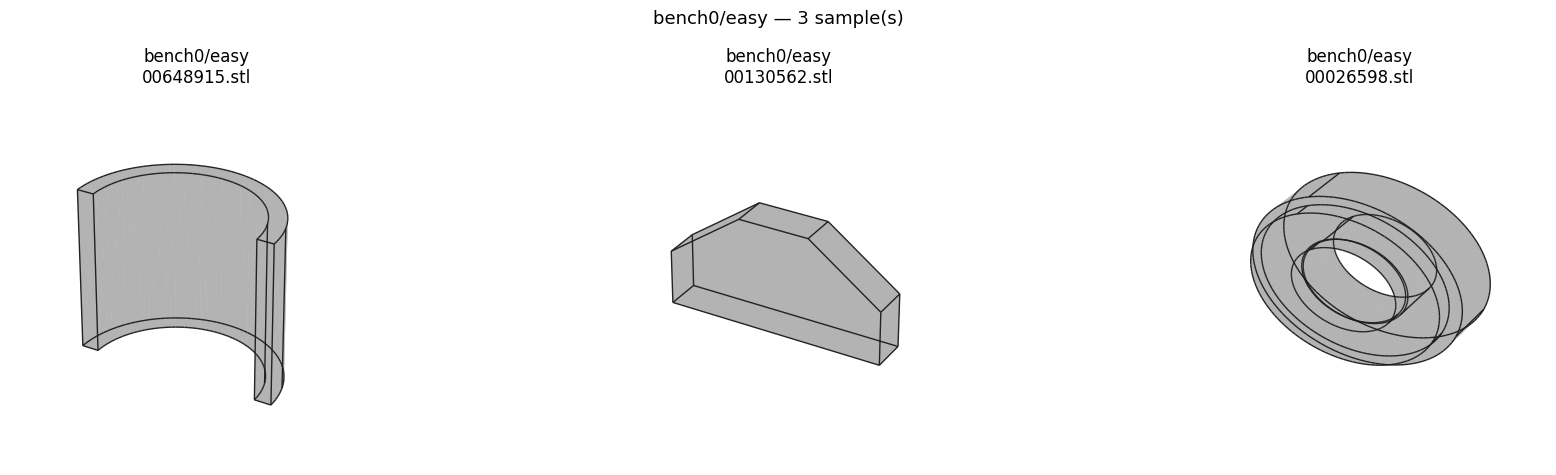


bench0/medium:
  - 00748963.stl
  - 00291571.stl
  - 00263620.stl


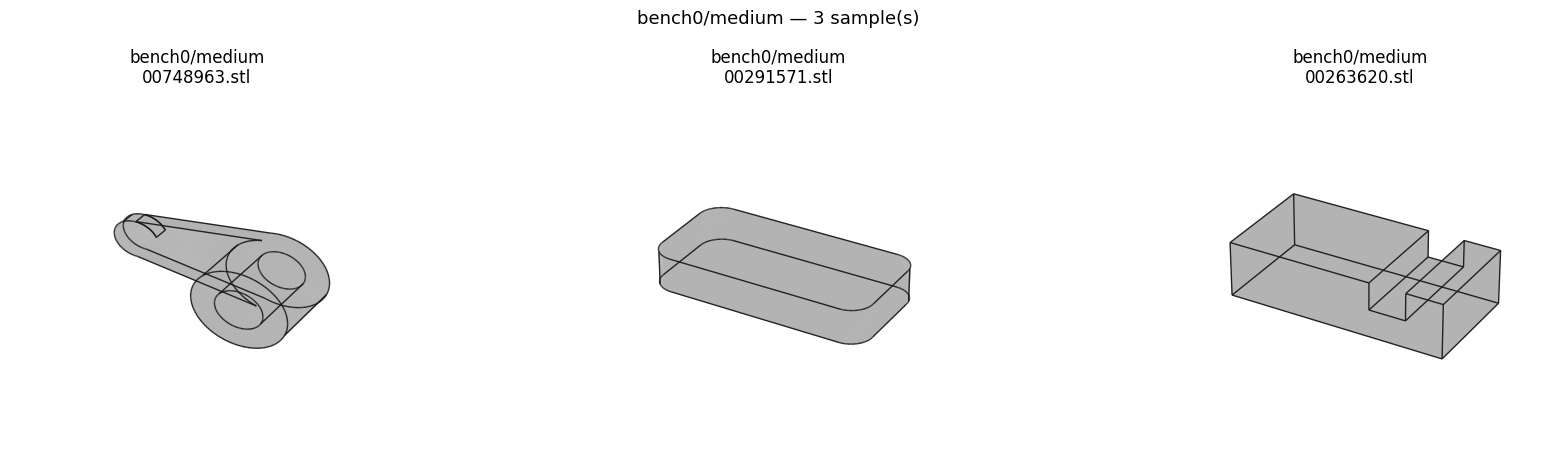


bench0/hard:
  - 00247338.stl
  - 00154647.stl
  - 00734010.stl


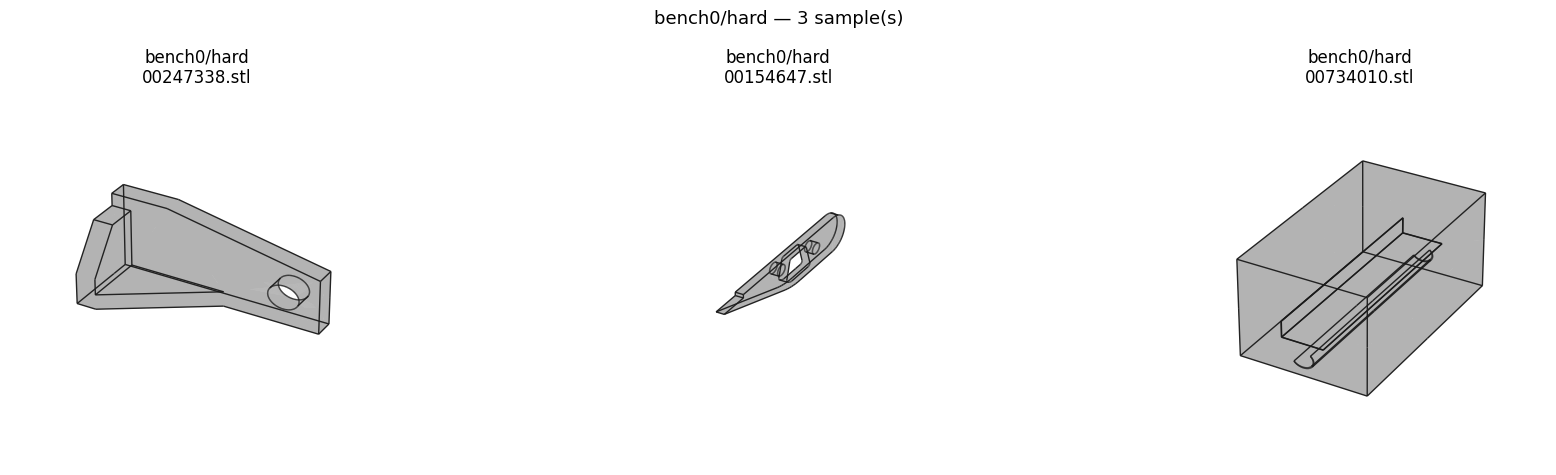


bench1A/easy:
  - 00096607_27cc89557663ccea31b09b11_step_014.stl
  - 00666651_ca70f90ac67ccf265e84e4ef_step_001.stl
  - 00733049_7f5fb636323cc707826d2720_step_001.stl


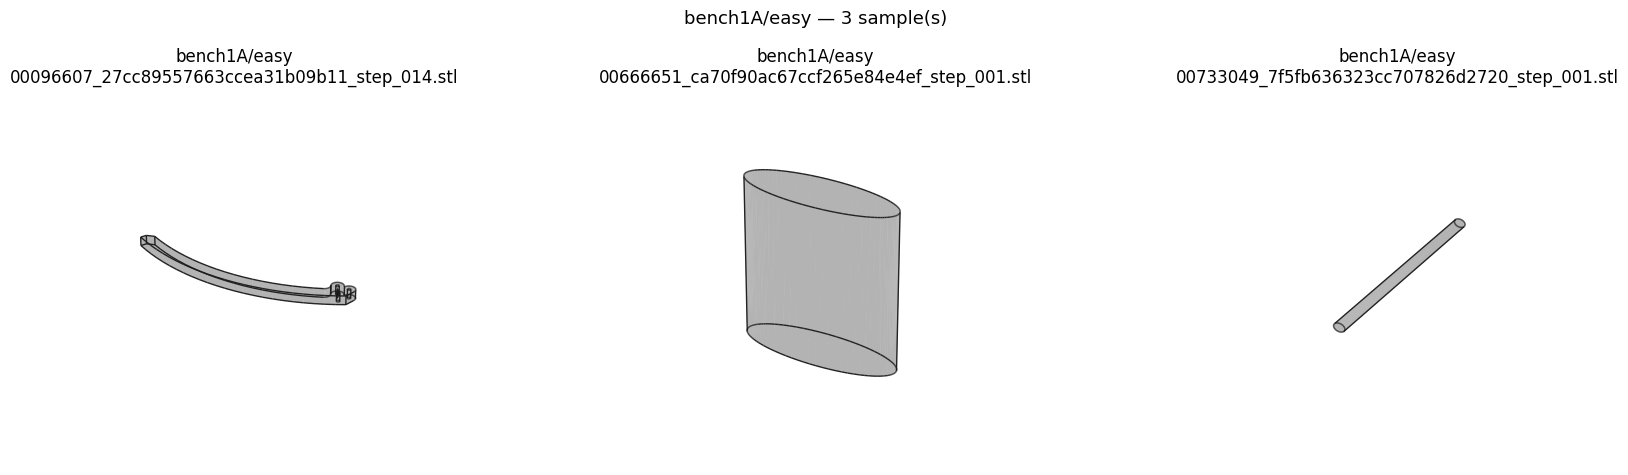


bench1A/medium:
  - 00899835_1c57720a5e7ddb3385edc5dc_step_000.stl
  - 00535746_c5c27c46b875610597ebc3fa_step_007.stl
  - 00063929_ad69fd53dda047dbafe4b9b9_step_000.stl


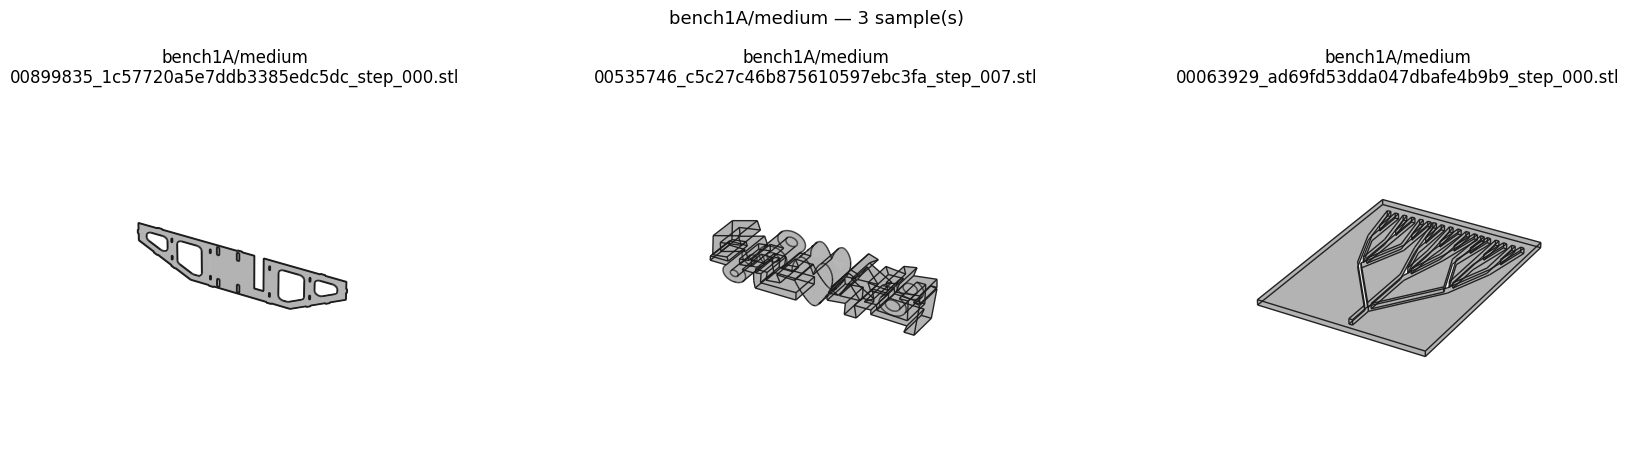


bench1A/hard:
  - 00575517_5650968f78b5fc89a2a662b0_step_005.stl
  - 00362904_279aaa6a3b9a28c7120ab590_step_001.stl
  - 00034116_50c7abbe52254f6683e9ddb9_step_002.stl


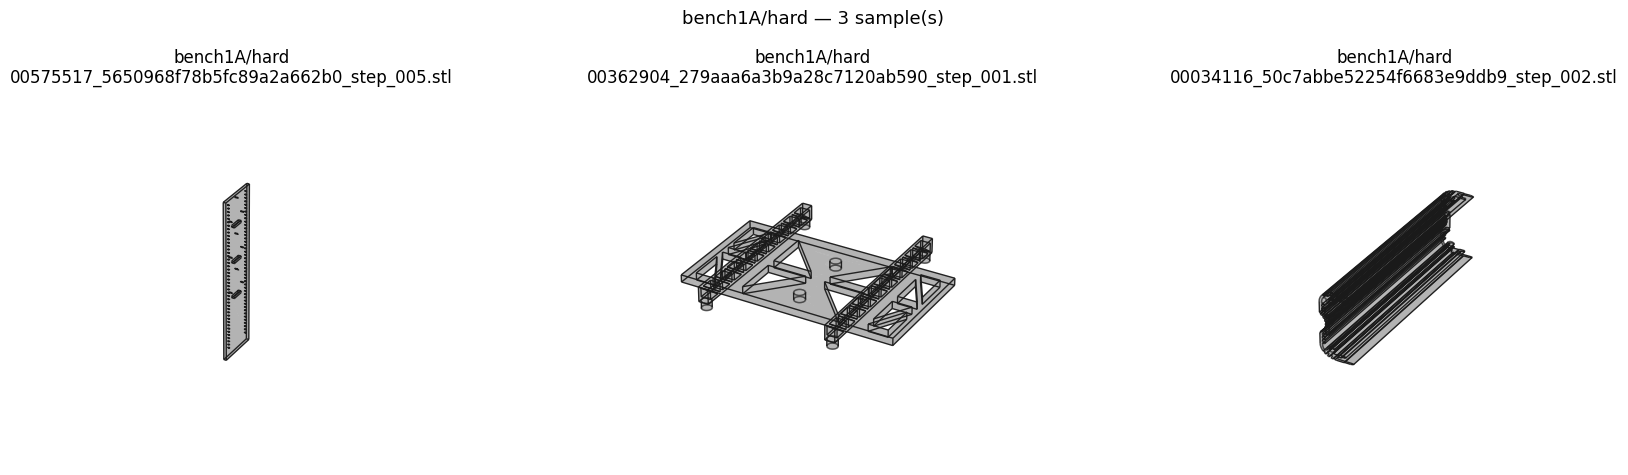


bench1B/easy:
  - 00023391_a7d22a103e9b4911b36a4486_step_000.stl
  - 00079692_7668c1cdb5b1104d8cd0823e_step_000.stl
  - 00203125_0abcc44011d8448587a82971_step_000.stl


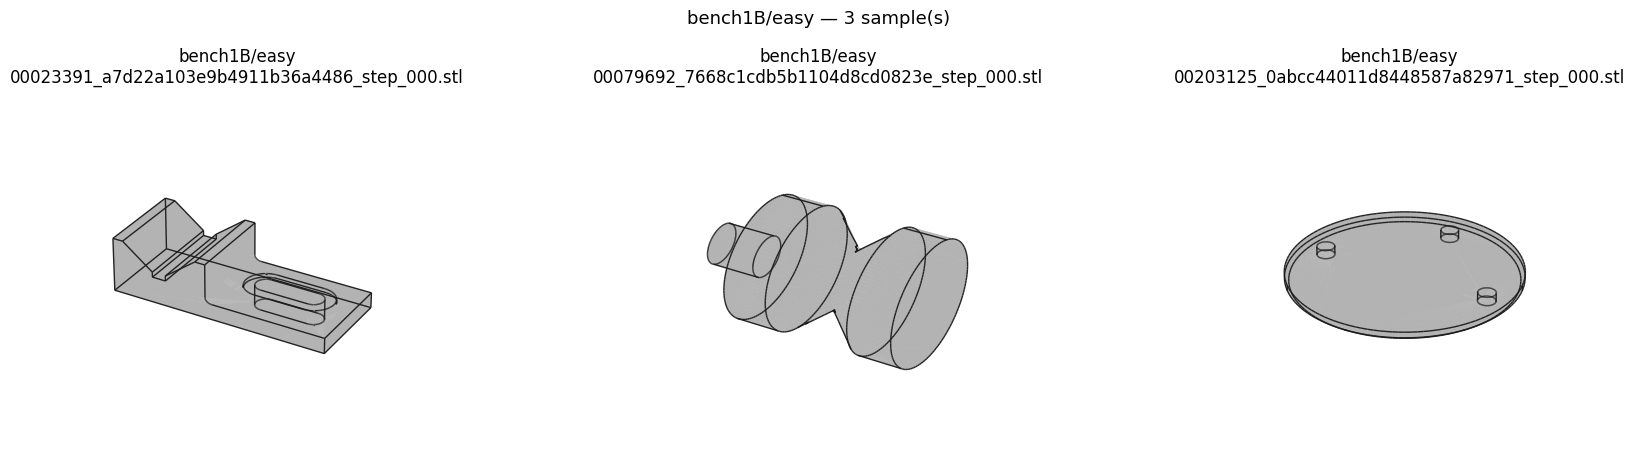


bench1B/medium:
  - 00225583_41cc33df719b92f833a0e971_step_013.stl
  - 00513683_d3dab87c196aaa174354e86a_step_000.stl
  - 00623177_e5e8197dfcc7d4554df41270_step_000.stl


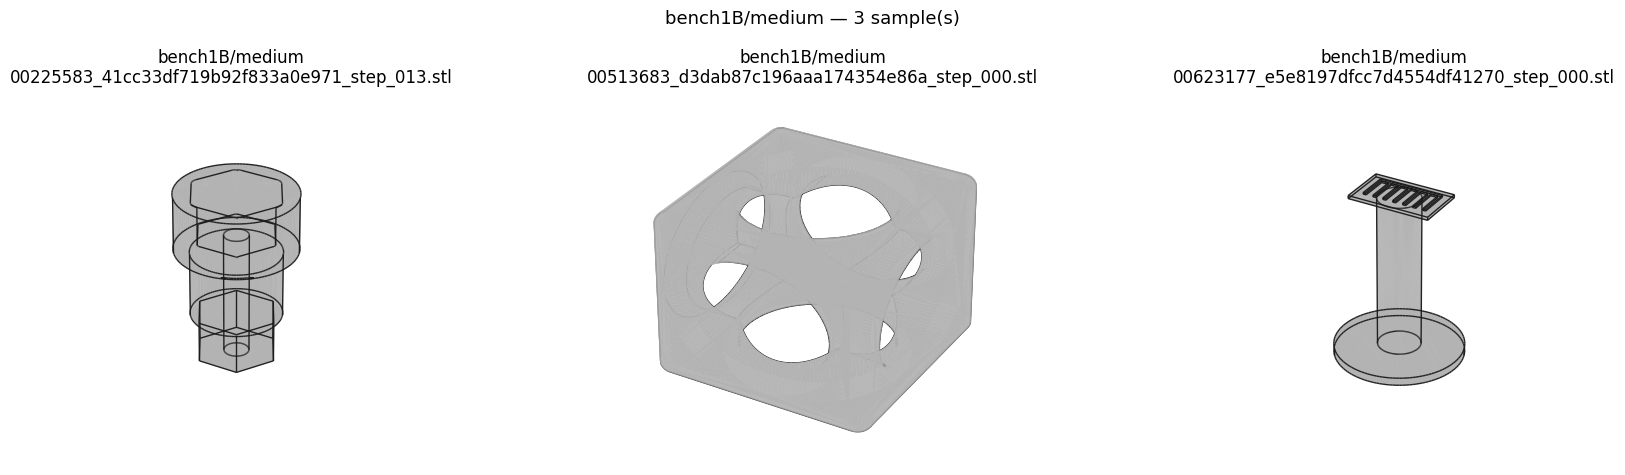


bench1B/hard:
  - 00023433_4ad8c83b30a6480cadfb1f82_step_000.stl
  - 00580544_f0c2a5b94229a62f02daa97d_step_000.stl
  - 00165909_e9a60cde3c422c7cc7c16930_step_000.stl


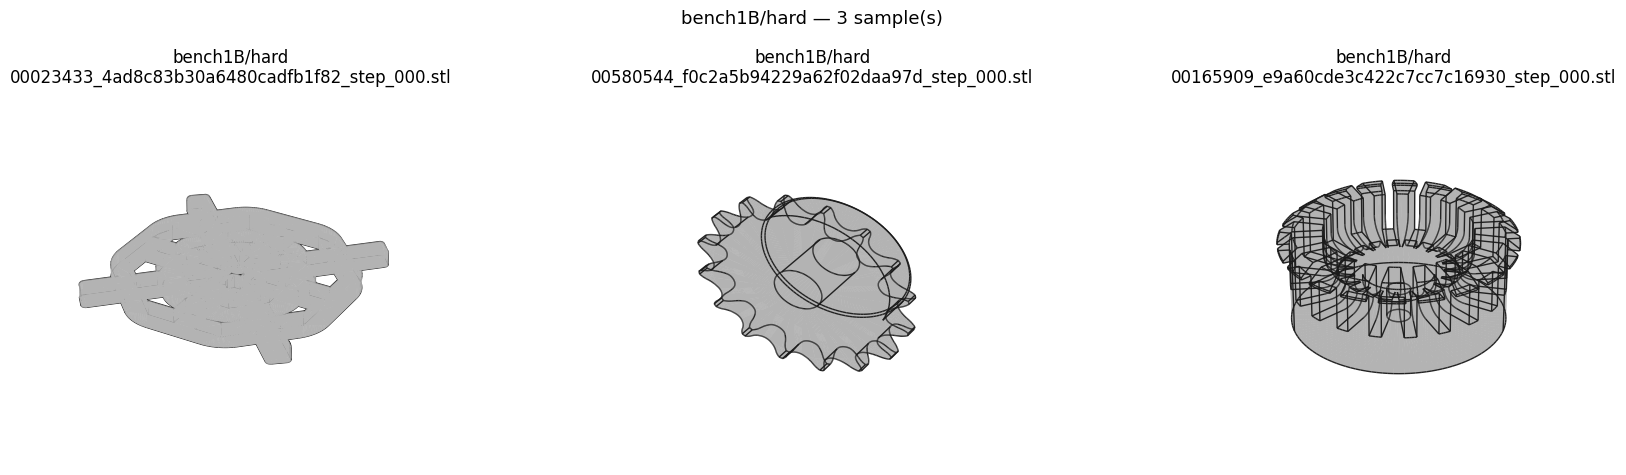


bench2:
  - 00057097.stl
  - 00052548.stl
  - 00056284.stl


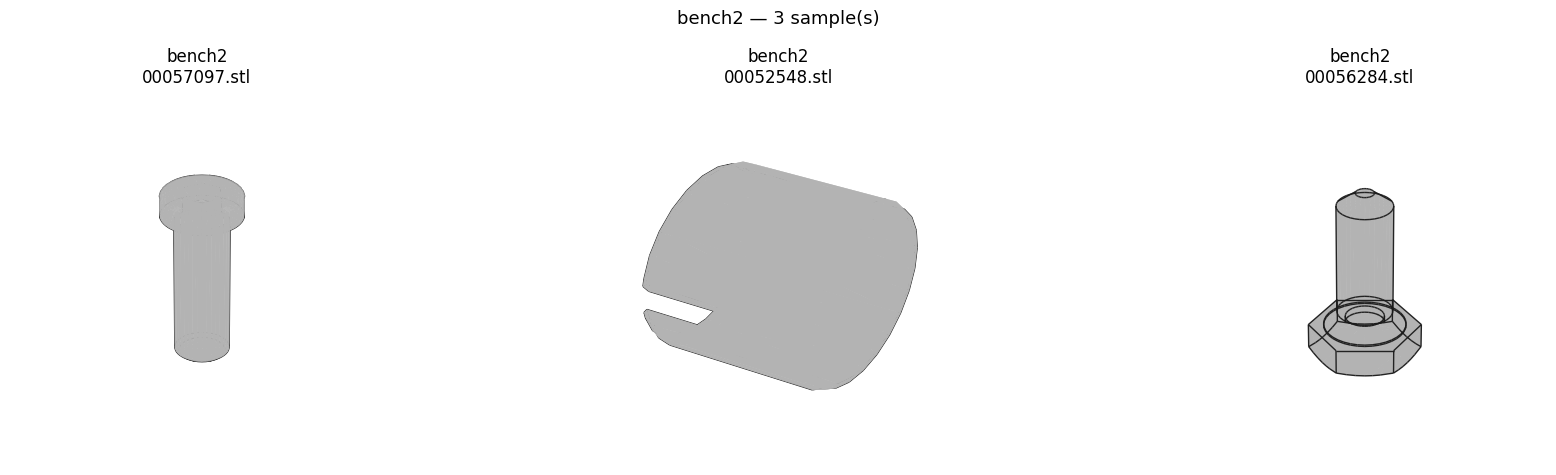


bench3:
  - bec1885893644c09985ddce4155f06fd.stl
  - 939aef38e6934d9688e1c6fa73e714c7.stl
  - 4d0e5894afdd4a0b8a327c45e905859f.stl


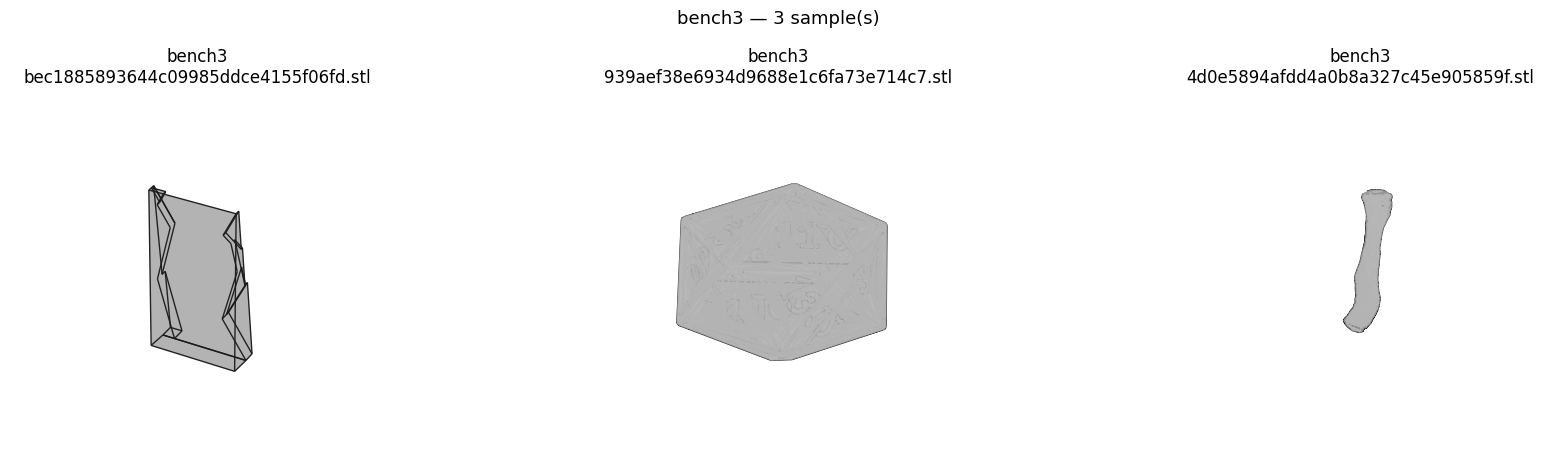

In [19]:
random.seed(RANDOM_SEED)

groups = list_groups(CADBENCH_ROOT, BENCH_ORDER)
print('Total groups to visualize:', len(groups))

for group_label, group_dir in groups:
    chosen = pick_samples(group_dir, SAMPLES_PER_GROUP, PICK_MODE)
    print(f'\n{group_label}:')
    for p in chosen:
        print('  -', p.name)
    plot_group_samples(group_label, chosen)